# Lab 8: RGB--HSV Round Trip
Chọn **Runtime → Change runtime type → T4 GPU**, rồi **Run all**.
Có thể tải `image.jpg` vào Files trước khi chạy; nếu không có, notebook dùng ảnh mẫu có sẵn.

Kết quả: ảnh, `metrics.csv`, báo cáo LaTeX và file `outputs/Lab8.zip`.
Thời gian GPU đã warm-up, đồng bộ; không tính truyền dữ liệu. Dùng GPU thật để đo speedup.


In [1]:
%pip -q install "numba-cuda[cu12]"


In [2]:
import time
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from numba import cuda, float32, float64

OUT = Path('outputs/Lab8')
OUT.mkdir(parents=True, exist_ok=True)

assert cuda.is_available(), 'Chọn Runtime > Change runtime type > T4 GPU rồi chạy lại.'
device = cuda.get_current_device()
print('GPU:', device.name)
MAX_THREADS = device.MAX_THREADS_PER_BLOCK
BLOCKS = [b for b in [(8, 8), (16, 16), (32, 16), (32, 32)]
          if b[0] * b[1] <= MAX_THREADS]
REPEATS = 3

def load_image(path='image.jpg'):
    if Path(path).exists():
        a = plt.imread(path)
        if np.issubdtype(a.dtype, np.floating):
            a = np.clip(a * 255, 0, 255).astype(np.uint8)
        return np.asarray(Image.fromarray(a).convert('RGB')).copy()
    # Ảnh mẫu có màu, cạnh và nhiễu; không cần tải file để Run all.
    y, x = np.indices((256, 256))
    a = np.stack((x, y, (x // 32 % 2) * 160 + 40), axis=-1)
    noise = np.random.default_rng(0).integers(-15, 16, a.shape)
    return np.clip(a + noise, 0, 255).astype(np.uint8)

image = load_image()
H, W = image.shape[:2]
gray = (0.299 * image[:, :, 0] + 0.587 * image[:, :, 1]
        + 0.114 * image[:, :, 2]).astype(np.uint8)
print('Ảnh:', image.shape)

def grid(block):
    return ((W + block[0] - 1) // block[0],
            (H + block[1] - 1) // block[1])

def gpu_time(run):
    run()  # Warm-up: không tính biên dịch JIT vào thời gian.
    cuda.synchronize()
    start = time.time()
    for _ in range(REPEATS):
        run()
    cuda.synchronize()
    return (time.time() - start) / REPEATS

def cpu_time(run):
    start = time.time()
    result = run()
    return result, time.time() - start

def show_images(items):
    fig, axes = plt.subplots(1, len(items), figsize=(4 * len(items), 4), squeeze=False)
    for ax, (title, a) in zip(axes[0], items):
        ax.imshow(a, cmap='gray', vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis('off')
    fig.tight_layout()
    fig.savefig(OUT / 'images.png', dpi=120)
    plt.show()

def save_image(name, a):
    Image.fromarray(a).save(OUT / name)

def save_results(rows, report_name, report_text):
    df = pd.DataFrame(rows)
    df.to_csv(OUT / 'metrics.csv', index=False)
    print(df.to_string(index=False))
    # Bảng LaTeX nhỏ, không cần thêm thư viện dựng báo cáo.
    def tex(v):
        return str(v).replace('_', r'\_')
    lines = [r'\begin{center}', r'\resizebox{\linewidth}{!}{',
             r'\begin{tabular}{' + 'l' * len(df.columns) + '}', r'\hline',
             ' & '.join(tex(c) for c in df.columns) + r' \\', r'\hline']
    for row in df.itertuples(index=False, name=None):
        lines.append(' & '.join(f'{v:.6g}' if isinstance(v, float) else tex(v)
                                for v in row) + r' \\')
    lines += [r'\hline', r'\end{tabular}', '}', r'\end{center}']
    (OUT / 'results.tex').write_text('\n'.join(lines), encoding='utf-8')
    (OUT / report_name).write_text(report_text, encoding='utf-8')
    shutil.make_archive(str(OUT), 'zip', OUT)
    print('Kết quả và báo cáo:', str(OUT) + '.zip (tải trong Files bên trái)')


GPU: Tesla T4
Ảnh: (256, 256, 3)


In [3]:
@cuda.jit
def rgb2hsv(src, hue, sat, val):
    x, y = cuda.grid(2)
    if x < src.shape[1] and y < src.shape[0]:
        r, g, b = src[y, x, 0] / 255.0, src[y, x, 1] / 255.0, src[y, x, 2] / 255.0
        hi, lo = max(r, g, b), min(r, g, b)
        delta = hi - lo
        h = 0.0
        if delta != 0:
            if hi == r:
                h = (60.0 * (g - b) / delta + 360.0) % 360.0
            elif hi == g:
                h = 60.0 * (b - r) / delta + 120.0
            else:
                h = 60.0 * (r - g) / delta + 240.0
        hue[y, x] = h
        sat[y, x] = delta / hi if hi > 0 else 0.0
        val[y, x] = hi

@cuda.jit
def hsv2rgb(hue, sat, val, dst):
    x, y = cuda.grid(2)
    if x < dst.shape[1] and y < dst.shape[0]:
        h = hue[y, x] / 60.0
        c = val[y, x] * sat[y, x]
        z = c * (1.0 - abs(h % 2.0 - 1.0))
        m = val[y, x] - c
        if h < 1: r, g, b = c, z, 0.0
        elif h < 2: r, g, b = z, c, 0.0
        elif h < 3: r, g, b = 0.0, c, z
        elif h < 4: r, g, b = 0.0, z, c
        elif h < 5: r, g, b = z, 0.0, c
        else: r, g, b = c, 0.0, z
        dst[y, x, 0] = min(255, max(0, int((r + m) * 255.0 + 0.5)))
        dst[y, x, 1] = min(255, max(0, int((g + m) * 255.0 + 0.5)))
        dst[y, x, 2] = min(255, max(0, int((b + m) * 255.0 + 0.5)))


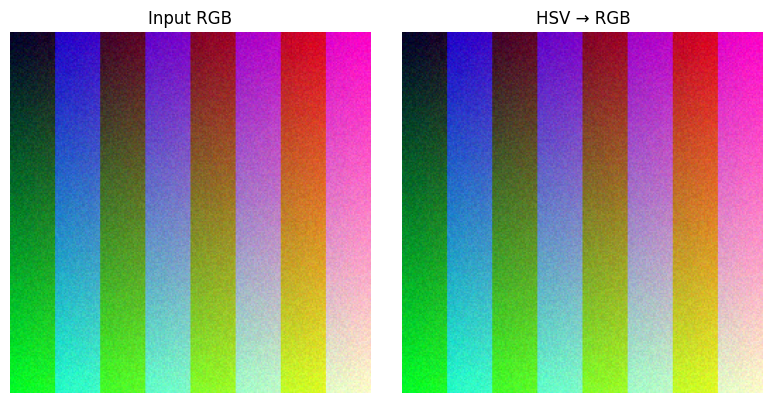

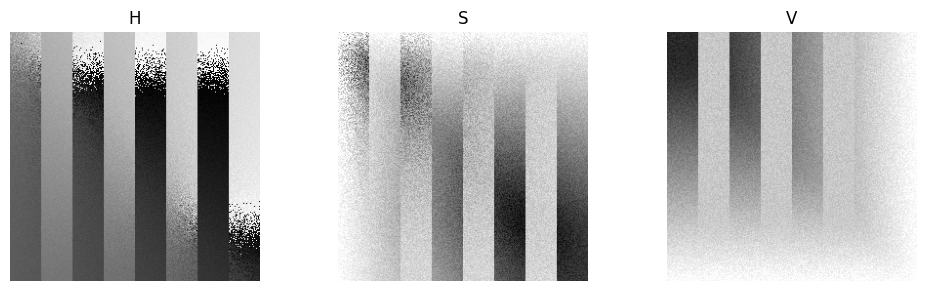

In [4]:
from matplotlib.colors import rgb_to_hsv
d_src = cuda.to_device(image)
d_h, d_s, d_v = [cuda.device_array((H, W), dtype=np.float32) for _ in range(3)]
d_dst = cuda.device_array_like(d_src)
block = (16, 16)
t1 = gpu_time(lambda: rgb2hsv[grid(block), block](d_src, d_h, d_s, d_v))
t2 = gpu_time(lambda: hsv2rgb[grid(block), block](d_h, d_s, d_v, d_dst))
hue, sat, val = [a.copy_to_host() for a in [d_h, d_s, d_v]]
result = d_dst.copy_to_host()
reference = rgb_to_hsv(image / 255.0)
hue_delta = np.abs(hue / 360.0 - reference[:, :, 0])
hue_error = float(np.minimum(hue_delta, 1 - hue_delta).max())
assert hue_error < 1e-5
assert np.allclose(sat, reference[:, :, 1], atol=1e-6)
assert np.allclose(val, reference[:, :, 2], atol=1e-6)
error = int(np.abs(result.astype(int) - image.astype(int)).max())
assert error <= 1
rows = [dict(rgb2hsv_ms=t1 * 1000, hsv2rgb_ms=t2 * 1000,
             hue_error=hue_error, max_rgb_error=error)]
np.savez(OUT / 'hsv.npz', H=hue, S=sat, V=val)
save_image('image_roundtrip.png', result)
show_images([('Input RGB', image), ('HSV → RGB', result)])
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, title, a, vmax in zip(axes, ['H', 'S', 'V'], [hue, sat, val], [360, 1, 1]):
    ax.imshow(a, cmap='gray', vmin=0, vmax=vmax); ax.set_title(title); ax.axis('off')
fig.tight_layout(); fig.savefig(OUT / 'hsv.png', dpi=120); plt.show()


In [5]:
report_text = r"""
\documentclass{article}
\usepackage[utf8]{inputenc}
\usepackage[T5]{fontenc}
\usepackage{graphicx}
\usepackage[margin=1.5cm]{geometry}
\title{Lab 8: RGB--HSV Round Trip}
\author{Nguyễn Thanh Hùng -- 2540056}
\date{}
\begin{document}
\maketitle
RGB2HSV scatters interleaved RGB into separate H, S and V arrays, with H in degrees and S,V in $[0,1]$.
HSV2RGB gathers them back into an RGB image. The notebook saves all three arrays, displays the round trip, checks HSV against Matplotlib and reports maximum RGB reconstruction error.

Kernel timing uses \texttt{time.time()} after JIT warm-up and CUDA synchronization,
averaged over three GPU runs. Device allocation and host/device copies are excluded.
CPU measurements are single runs. Speedup is relative to the stated CPU implementation.
Actual measurements appear after running the notebook on Colab; no timings are assumed here.
\IfFileExists{results.tex}{\input{results.tex}}{}
\IfFileExists{performance.png}{\begin{center}\includegraphics[width=.75\linewidth]{performance.png}\end{center}}{}
\IfFileExists{images.png}{\begin{center}\includegraphics[width=\linewidth]{images.png}\end{center}}{}
\IfFileExists{histograms.png}{\begin{center}\includegraphics[width=.8\linewidth]{histograms.png}\end{center}}{}
\end{document}
"""
save_results(rows, 'Report.8.scatter.tex', report_text)


 rgb2hsv_ms  hsv2rgb_ms    hue_error  max_rgb_error
   0.189225    0.121673 7.085279e-08              0
Kết quả và báo cáo: outputs/Lab8.zip (tải trong Files bên trái)


In [6]:
import json as _json, platform as _platform
from pathlib import Path as _Path
from numba import cuda as _cuda
_out = _Path('outputs/Lab8')
_out.mkdir(parents=True, exist_ok=True)
_device = _cuda.get_current_device()
_name = _device.name
if isinstance(_name, bytes): _name = _name.decode()
(_out / 'environment.json').write_text(_json.dumps({
    'gpu': str(_name), 'python': _platform.python_version(),
    'compute_capability': list(_device.compute_capability)
}, indent=2), encoding='utf-8')
if 'image' in globals():
    from PIL import Image as _Image
    _Image.fromarray(image).save(_out / 'input.png')
if 'second' in globals():
    _Image.fromarray(second).save(_out / 'input2.png')
